In [1]:
# === Run this cell FIRST (works even if the notebook is inside /Model) ===
import os, sys, pathlib

# Add the project root (the folder that contains `project_package/`) to Python path
def add_project_root(marker_folder="project_package", max_up=5):
    cur = pathlib.Path(".").resolve()
    for _ in range(max_up + 1):
        if (cur / marker_folder).is_dir():
            if str(cur) not in sys.path:
                sys.path.insert(0, str(cur))
            return cur
        cur = cur.parent
    raise RuntimeError(f"Could not find '{marker_folder}' up to {max_up} levels above.")

PROJECT_ROOT = add_project_root()
print("PROJECT_ROOT =", PROJECT_ROOT)

# Resolve CSV location (here we assume it's at the project root; move to /datasets if you prefer)
CSV_NAME = "ncr_ride_bookings_with_weather_filled_scaled_short.csv"
csv_path = PROJECT_ROOT / CSV_NAME
print("CSV exists:", csv_path.exists(), "->", csv_path)

# Import unsupervised runners from your package
from project_package.modeling import (
    run_kmeans_from_csv,
    run_isolation_forest_from_csv,
    run_pca_embeddings_from_csv,
)

# ID columns to carry through outputs (useful for later joins/plots)
IDS = ["Booking ID", "Customer ID"]

# --- 1) KMeans clustering ---
# Tries multiple k, picks the best by silhouette; exports labels and PCA(2D) CSVs.
km = run_kmeans_from_csv(
    csv_path=str(csv_path),
    id_cols=IDS,
    artifacts_dir="unsupervised",   # will be saved under <project_root>/artifacts/unsupervised/
    k_list=[3, 5, 8, 10],
    random_state=42,
)
print("Best k:", km.best_k)
print("Quality per k:", km.report)
print("Labels CSV:", km.labels_csv_path)
print("PCA(2D) CSV:", km.pca2_csv_path)

# --- 2) Isolation Forest (anomaly detection) ---
# Flags unusual rows; contamination ≈ expected outlier fraction.
iso = run_isolation_forest_from_csv(
    csv_path=str(csv_path),
    id_cols=IDS,
    artifacts_dir="unsupervised",
    contamination=0.02,
    random_state=42,
)
print("Anomaly scores CSV:", iso.scores_csv_path)

# --- 3) PCA embeddings (2D) ---
# Produces 2D coordinates (pc1, pc2) for easy scatter plotting.
emb = run_pca_embeddings_from_csv(
    csv_path=str(csv_path),
    id_cols=IDS,
    artifacts_dir="unsupervised",
    n_components=2,
    random_state=42,
)
print("PCA embeddings CSV:", emb.embed_csv_path)


PROJECT_ROOT = /Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis
CSV exists: True -> /Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis/ncr_ride_bookings_with_weather_filled_scaled_short.csv
Best k: 5
Quality per k: {3: {'silhouette': 0.35546941295015305, 'dbi': 0.9052378837460658, 'ch': 104492.29810742913}, 5: {'silhouette': 0.35655068727132627, 'dbi': 0.9159452513668309, 'ch': 120780.94401266333}, 8: {'silhouette': 0.31599906638856795, 'dbi': 0.9038054921448941, 'ch': 118250.4249843495}, 10: {'silhouette': 0.31100158385381776, 'dbi': 0.9473177744164459, 'ch': 113979.6711039582}}
Labels CSV: /Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis/unsupervised/kmeans_k5_labels.csv
PCA(2D) CSV: /Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis/unsupervised/kmeans_k5_pca2.csv
Anomaly scores CSV: /Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis/unsupervised/isoforest_scores.csv
PCA embeddings CSV: /Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis/unsupervised

Show Model Result in a Table and Graph

In [3]:
results = km.report

    k  silhouette       dbi             ch
0   3    0.355469  0.905238  104492.298107
1   5    0.356551  0.915945  120780.944013
2   8    0.315999  0.903805  118250.424984
3  10    0.311002  0.947318  113979.671104


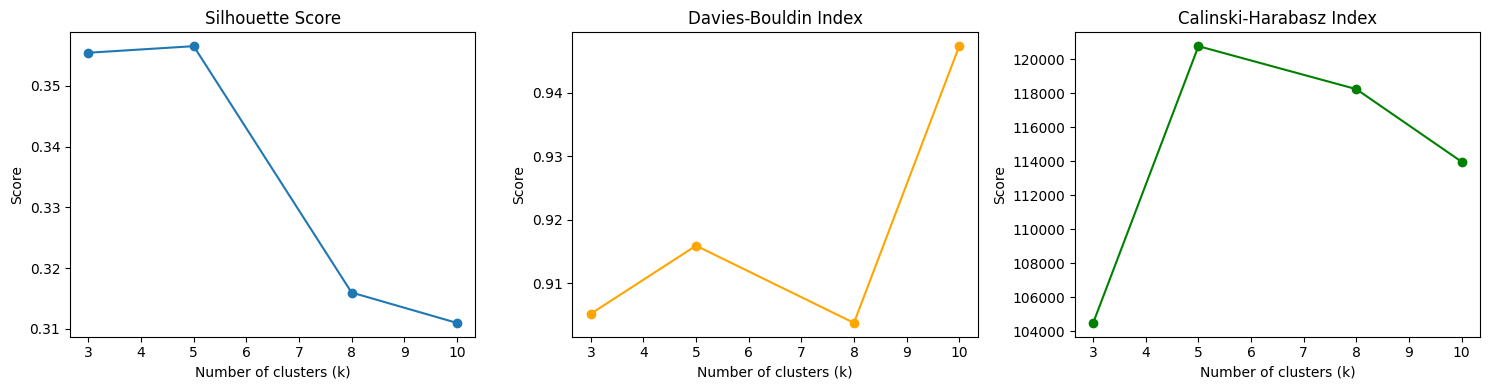

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to DataFrame
df_results = pd.DataFrame(results).T.reset_index()
df_results.rename(columns={'index': 'k'}, inplace=True)

# Show table
print(df_results)

# Plot metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df_results['k'], df_results['silhouette'], marker='o')
axes[0].set_title("Silhouette Score")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Score")

axes[1].plot(df_results['k'], df_results['dbi'], marker='o', color='orange')
axes[1].set_title("Davies-Bouldin Index")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Score")

axes[2].plot(df_results['k'], df_results['ch'], marker='o', color='green')
axes[2].set_title("Calinski-Harabasz Index")
axes[2].set_xlabel("Number of clusters (k)")
axes[2].set_ylabel("Score")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Summary Table
# =========================
def build_unsup_summary(metrics: dict, best_k: int, contamination: float = 0.02):
    """Build overall summary table for unsupervised models."""
    df_summary = pd.DataFrame({
        "Method": ["KMeans", "Isolation Forest"],
        "Best Params": [f"k={best_k}", f"contamination={contamination}"],
        "Silhouette": [metrics[best_k]["silhouette"], None],
        "DBI": [metrics[best_k]["dbi"], None],
        "CH Score": [metrics[best_k]["ch"], None],
        "Notes": [
            "Best clustering separation across tested k values",
            "≈2% of rides flagged as anomalies"
        ]
    })
    return df_summary


# =========================
# 2. KMeans Visualizations
# =========================
def plot_kmeans_clusters(pca_csv: str):
    """PCA scatter of KMeans clusters."""
    df = pd.read_csv(pca_csv)
    plt.figure(figsize=(8,6))
    plt.scatter(df['pc1'], df['pc2'], c=df['cluster'], cmap="tab10", alpha=0.6, s=15)
    plt.title("KMeans Clusters in PCA Space")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.colorbar(label="Cluster")
    plt.show()

def plot_kmeans_profiles(main_csv: str, labels_csv: str, features=None):
    """Cluster feature profiles (mean values)."""
    df_main = pd.read_csv(main_csv)
    df_labels = pd.read_csv(labels_csv)
    df = df_main.merge(df_labels, on="Booking ID")

    if features is None:
        # fallback: top-5 most variable numeric features
        num_cols = df.select_dtypes(include=[np.number]).columns.drop(["cluster"], errors="ignore")
        features = df[num_cols].var().sort_values(ascending=False).head(5).index.tolist()

    cluster_profiles = df.groupby("cluster")[features].mean()
    cluster_profiles.plot(kind="bar", figsize=(10,6))
    plt.title("Cluster Profiles (Mean Values)")
    plt.ylabel("Average Value")
    plt.show()


# =========================
# 3. Isolation Forest Visualizations
# =========================
def plot_iso_hist(scores_csv: str):
    """Histogram of anomaly scores."""
    df = pd.read_csv(scores_csv)
    plt.figure(figsize=(8,6))
    plt.hist(df['anomaly_score'], bins=50, color="steelblue", alpha=0.7)
    plt.title("Isolation Forest Anomaly Score Distribution")
    plt.xlabel("Anomaly Score")
    plt.ylabel("Frequency")
    plt.show()

def plot_iso_pca(pca_csv: str, scores_csv: str):
    """PCA scatter with anomalies highlighted."""
    df_pca = pd.read_csv(pca_csv)
    df_iso = pd.read_csv(scores_csv)
    df = df_pca.merge(df_iso, on="Booking ID")

    plt.figure(figsize=(8,6))
    plt.scatter(df.loc[df['is_outlier']==0, 'pc1'],
                df.loc[df['is_outlier']==0, 'pc2'],
                c="lightgray", alpha=0.5, s=12, label="Normal")
    plt.scatter(df.loc[df['is_outlier']==1, 'pc1'],
                df.loc[df['is_outlier']==1, 'pc2'],
                c="red", marker="x", s=30, label="Outlier")
    plt.title("Isolation Forest Outliers in PCA Space")
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
    plt.show()


# =========================
# 4. Sensitivity Analysis
# =========================
def plot_kmeans_sensitivity(metrics: dict):
    """Plot silhouette and CH score across k values."""
    df = pd.DataFrame(metrics).T.reset_index().rename(columns={"index":"k"})

    fig, ax1 = plt.subplots(figsize=(8,6))
    ax1.plot(df['k'], df['silhouette'], marker='o', color="blue", label="Silhouette")
    ax1.set_xlabel("k"); ax1.set_ylabel("Silhouette", color="blue")
    ax1.tick_params(axis='y', labelcolor="blue")

    ax2 = ax1.twinx()
    ax2.plot(df['k'], df['ch'], marker='s', color="orange", label="CH Score")
    ax2.set_ylabel("Calinski–Harabasz", color="orange")
    ax2.tick_params(axis='y', labelcolor="orange")

    plt.title("KMeans Sensitivity Analysis")
    plt.show()


             Method         Best Params  Silhouette       DBI       CH Score  \
0            KMeans                 k=5    0.356551  0.915945  120780.944013   
1  Isolation Forest  contamination=0.02         NaN       NaN            NaN   

                                               Notes  
0  Best clustering separation across tested k values  
1                  ≈2% of rides flagged as anomalies  


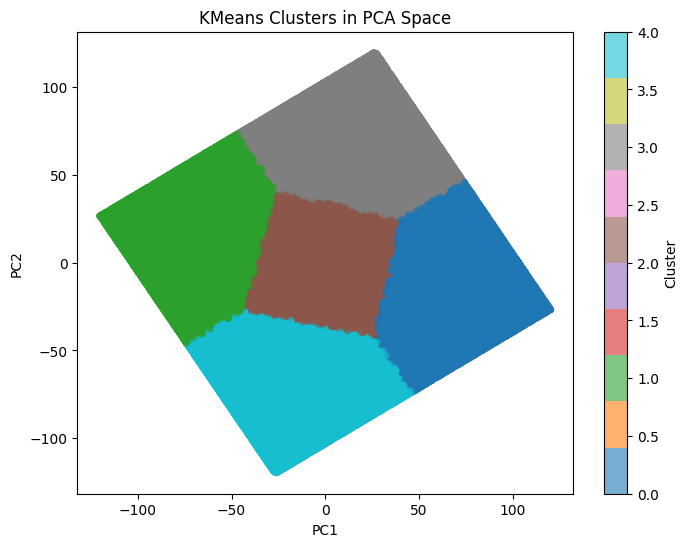

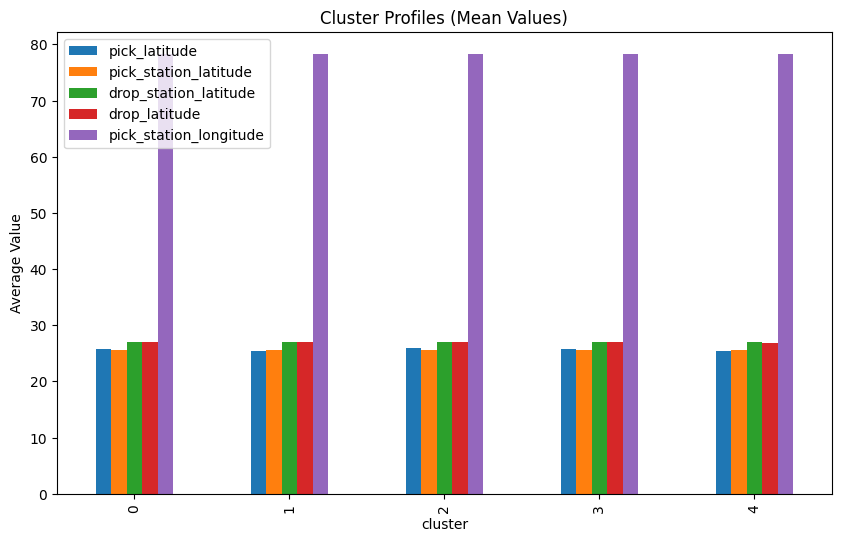

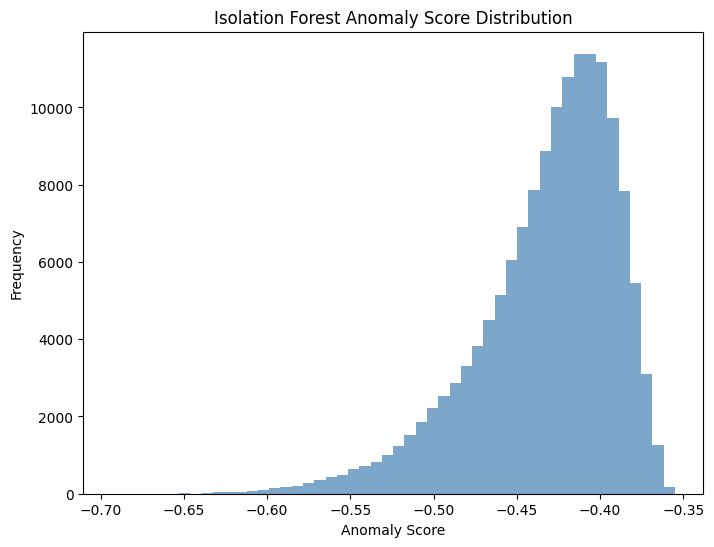

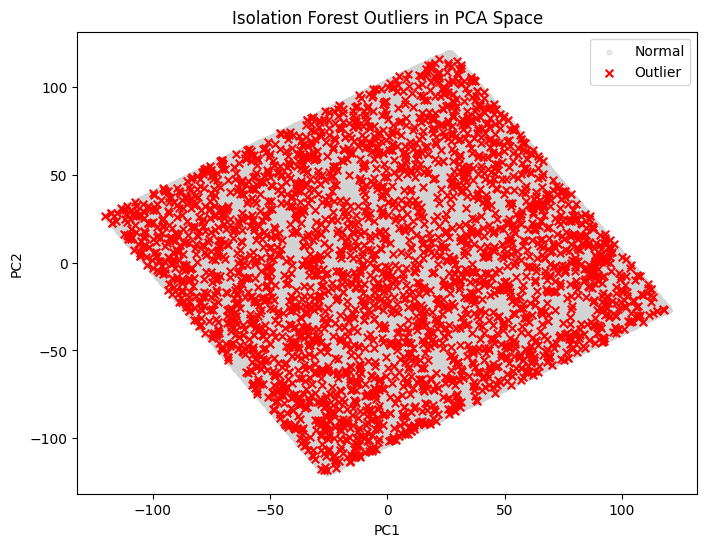

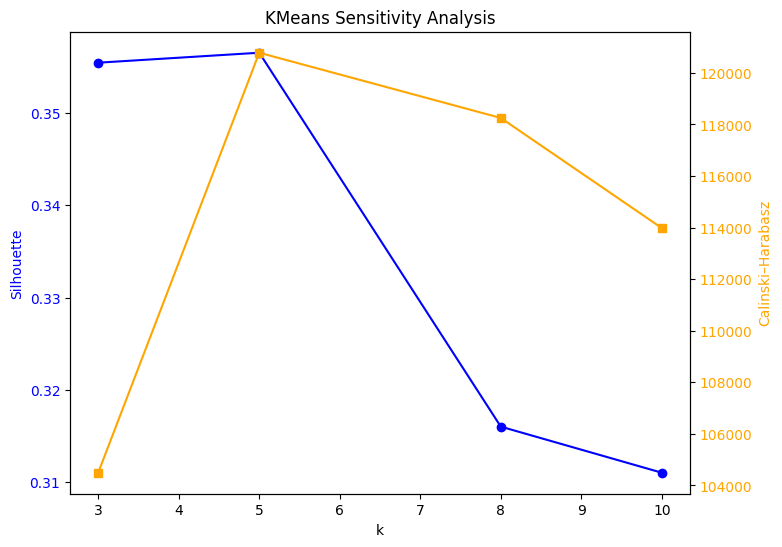

In [6]:
# Inputs
PROJECT_ROOT = "/Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis"
main_csv = f"{PROJECT_ROOT}/ncr_ride_bookings_with_weather_filled_scaled_short.csv"
pca_csv = f"{PROJECT_ROOT}/unsupervised/kmeans_k5_pca2.csv"
labels_csv = f"{PROJECT_ROOT}/unsupervised/kmeans_k5_labels.csv"
iso_scores = f"{PROJECT_ROOT}/unsupervised/isoforest_scores.csv"
pca_all = f"{PROJECT_ROOT}/unsupervised/pca_2d.csv"

metrics = results

# 1) Summary table
summary = build_unsup_summary(metrics, best_k=5)
print(summary)

# 2) Visualizations
plot_kmeans_clusters(pca_csv)
plot_kmeans_profiles(main_csv, labels_csv)
plot_iso_hist(iso_scores)
plot_iso_pca(pca_all, iso_scores)

# 3) Sensitivity analysis
plot_kmeans_sensitivity(metrics)